In [ ]:
import os
import pickle
import pyreadr
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Display Options
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid")

# Define directory of data folder
data_dir = os.path.join("..", "Data")

# Load Model results across datasets

In [18]:
# ==========================================
# DATA LOADING FUNCTIONS
# ==========================================

def load_liesel_data(pkl_path):
    print(f"Loading Liesel data from: {os.path.abspath(pkl_path)}")
    if not os.path.exists(pkl_path):
        raise FileNotFoundError(f"Pickle file not found: {pkl_path}")
        
    with open(pkl_path, "rb") as f:
        saved_data = pickle.load(f)
        
    samples = saved_data["samples"]
    beta_raw = samples['beta_i']
    
    # Flatten Chains and Draws: (Chains, Draws, Units, Params) -> (Total_Draws, Units, Params)
    n_chains, n_draws, n_units, n_params = beta_raw.shape
    beta_liesel_flat = beta_raw.reshape(n_chains * n_draws, n_units, n_params)
    
    # Flatten Mu: (Chains, Draws, Params) -> (Total_Draws, Params)
    mu_liesel_flat = samples['mu'].reshape(-1, samples['mu'].shape[2])
    
    print(f"  -> Liesel Beta shape (flattened): {beta_liesel_flat.shape}")
    print(f"  -> Liesel Mu shape (flattened): {mu_liesel_flat.shape}")
    
    return beta_liesel_flat, mu_liesel_flat

def load_bayesm_data(r_path):
    print(f"Loading bayesm data from: {os.path.abspath(r_path)}")
    if not os.path.exists(r_path):
        raise FileNotFoundError(f"RData file not found: {r_path}")
        
    r_result = pyreadr.read_r(r_path)
    
    # Extract Mu
    mu_df = r_result['mu_draws_df']
    mu_r_samples = mu_df.to_numpy()
    
    # Extract Beta
    beta_df = r_result['beta_draws_df']
    n_units = beta_df['Unit_ID'].nunique()
    n_samples_r = len(beta_df) // n_units
    
    param_cols = [c for c in beta_df.columns if c not in ['Unit_ID', 'Draw_ID']]
    n_params = len(param_cols)
    
    # Sort and Reshape: (Draws, Units, Params)
    beta_df_sorted = beta_df.sort_values(by=['Draw_ID', 'Unit_ID'])
    beta_flat_r = beta_df_sorted[param_cols].to_numpy()
    beta_r_samples = beta_flat_r.reshape(n_samples_r, n_units, n_params)
    
    print(f"  -> bayesm Beta shape: {beta_r_samples.shape}")
    print(f"  -> bayesm Mu shape: {mu_r_samples.shape}")
    
    return beta_r_samples, mu_r_samples, param_cols

In [19]:
# ==========================================
# PLOTTING FUNCTIONS
# ==========================================

def get_grid_dims(n_items, max_cols=5):
    """Calculates grid rows and columns dynamically."""
    cols = min(max_cols, n_items)
    rows = math.ceil(n_items / cols)
    return rows, cols

def plot_unit_comparison(unit_idx, r_data, liesel_data, param_names, dataset_name=""):
    rows, cols = get_grid_dims(len(param_names))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), constrained_layout=True)
    fig.suptitle(f'[{dataset_name}] Posterior Distributions for Unit {unit_idx}', fontsize=16)
    
    axes = np.atleast_1d(axes).flatten()
    
    for i, param in enumerate(param_names):
        ax = axes[i]
        sns.kdeplot(r_data[:, unit_idx, i], ax=ax, color='blue', fill=True, alpha=0.2, label='bayesm', linewidth=2)
        sns.kdeplot(liesel_data[:, unit_idx, i], ax=ax, color='orange', fill=True, alpha=0.2, label='Liesel', linewidth=2)
        
        ax.set_title(param)
        ax.set_ylabel("") 
        ax.set_yticks([]) 
        if i == 0: ax.legend(loc='upper left')

    # Hide unused subplots
    for j in range(len(param_names), len(axes)):
        axes[j].axis('off')
        
    plt.show()

def plot_parameter_recovery_means(r_data, liesel_data, param_names, dataset_name=""):
    r_betas_mean = np.mean(r_data, axis=0)
    py_betas_mean = np.mean(liesel_data, axis=0)
    
    rows, cols = get_grid_dims(len(param_names))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), constrained_layout=True)
    fig.suptitle(f"[{dataset_name}] Parameter Recovery: R vs Python (Posterior Means)", fontsize=16)
    
    axes = np.atleast_1d(axes).flatten()
    
    for i, param in enumerate(param_names):
        ax = axes[i]
        x_val = r_betas_mean[:, i]
        y_val = py_betas_mean[:, i]
        
        corr = np.corrcoef(x_val, y_val)[0, 1]
        
        ax.scatter(x_val, y_val, alpha=0.5, s=15, color='teal')
        
        plot_min = min(np.min(x_val), np.min(y_val))
        plot_max = max(np.max(x_val), np.max(y_val))
        ax.plot([plot_min, plot_max], [plot_min, plot_max], 'r--', alpha=0.75, zorder=0, label='Identity Line')
        
        ax.set_title(f"{param}\nCorr: {corr:.3f}")
        ax.set_xlabel("R (bayesm) Mean")
        ax.set_ylabel("Python (Liesel) Mean")
        ax.grid(True, alpha=0.3)

    for j in range(len(param_names), len(axes)):
        axes[j].axis('off')
        
    plt.show()

def plot_posterior_sds(r_data, liesel_data, dataset_name=""):
    # Calculate SD across draws (axis 0)
    r_flat = np.std(r_data, axis=0).flatten()
    py_flat = np.std(liesel_data, axis=0).flatten()

    plt.figure(figsize=(6, 6))
    limit = max(r_flat.max(), py_flat.max())

    plt.scatter(r_flat, py_flat, alpha=0.3, color='purple', s=10)
    plt.plot([0, limit], [0, limit], 'k--', label="Perfect Agreement")

    plt.xlabel("bayesm Posterior SD")
    plt.ylabel("Liesel Posterior SD")
    plt.title(f"[{dataset_name}] Comparing Posterior Standard Deviations")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_global_comparison(r_mu, liesel_mu, param_names, dataset_name=""):
    rows, cols = get_grid_dims(len(param_names))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), constrained_layout=True)
    fig.suptitle(f'[{dataset_name}] Global Parameters (Population Means): bayesm vs Liesel', fontsize=16)

    axes = np.atleast_1d(axes).flatten()

    for i, param in enumerate(param_names):
        ax = axes[i]
        sns.kdeplot(r_mu[:, i], ax=ax, color='blue', fill=True, alpha=0.2, label='bayesm', linewidth=2)
        sns.kdeplot(liesel_mu[:, i], ax=ax, color='orange', fill=True, alpha=0.2, label='Liesel', linewidth=2)
        
        ax.set_title(param)
        ax.set_ylabel("")
        ax.set_yticks([])
        if i == 0: ax.legend(loc='upper left')

    for j in range(len(param_names), len(axes)):
        axes[j].axis('off')

    plt.show()

In [20]:
# ==========================================
# ANALYSIS WRAPPER
# ==========================================
def run_full_analysis(dataset_name, data_dir, liesel_filename, bayesm_filename, param_names_override=None):
    print(f"\n{'='*50}\nAnalysis for: {dataset_name}\n{'='*50}")
    
    path_liesel = os.path.join(data_dir, liesel_filename)
    path_bayesm = os.path.join(data_dir, bayesm_filename)
    
    # Load Data
    b_liesel, mu_liesel = load_liesel_data(path_liesel)
    b_r, mu_r, r_param_names = load_bayesm_data(path_bayesm)
    
    # Resolve parameter names
    param_names = param_names_override if param_names_override else r_param_names
    
    # Plot unit-level posteriors (first and last unit)
    first_unit, last_unit = 0, b_r.shape[1] - 1
    plot_unit_comparison(first_unit, b_r, b_liesel, param_names, dataset_name)
    plot_unit_comparison(last_unit, b_r, b_liesel, param_names, dataset_name)
    
    # Plot Population Means
    plot_global_comparison(mu_r, mu_liesel, param_names, dataset_name)
    
    # Parameter Recovery Scatter (Means)
    plot_parameter_recovery_means(b_r, b_liesel, param_names, dataset_name)
    
    # Posterior SDs Scatter
    plot_posterior_sds(b_r, b_liesel, dataset_name)

## Simulated Dataset


Analysis for: Simulated Dataset
Loading Liesel data from: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data\liesel_output_simulated_40000_samples.pkl
  -> Liesel Beta shape (flattened): (40000, 100, 5)
  -> Liesel Mu shape (flattened): (40000, 5)
Loading bayesm data from: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data\bayesm_output_simulated_40000_samples.RData
  -> bayesm Beta shape: (40000, 100, 5)
  -> bayesm Mu shape: (40000, 5)


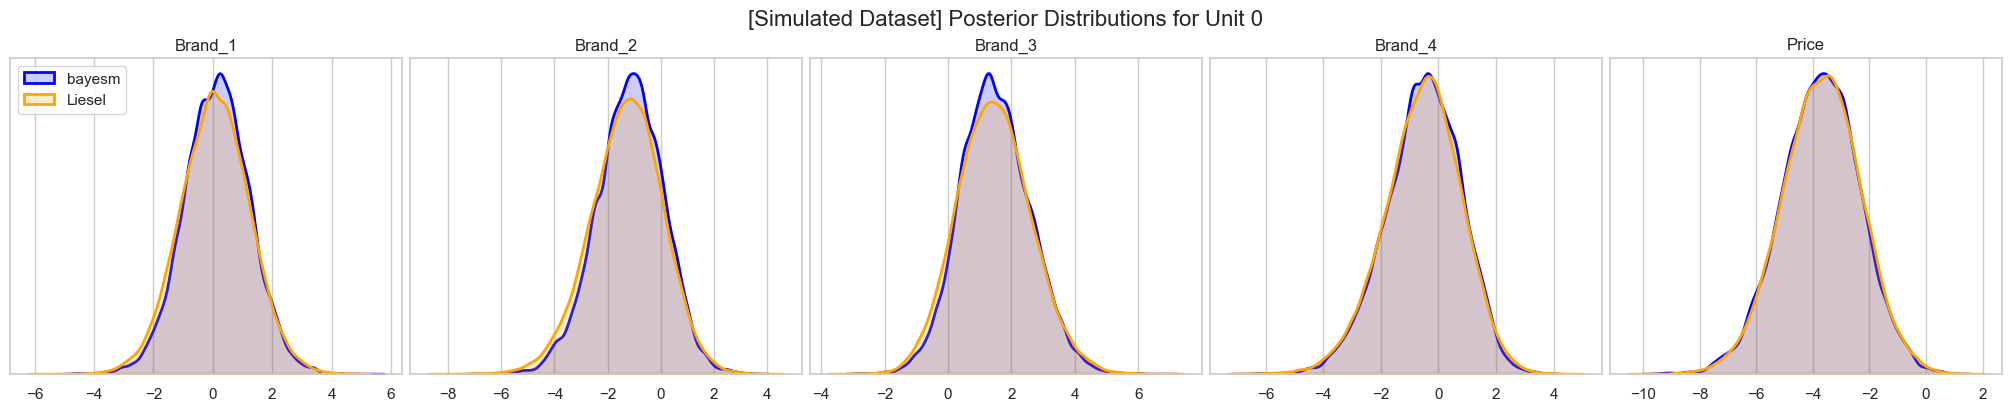

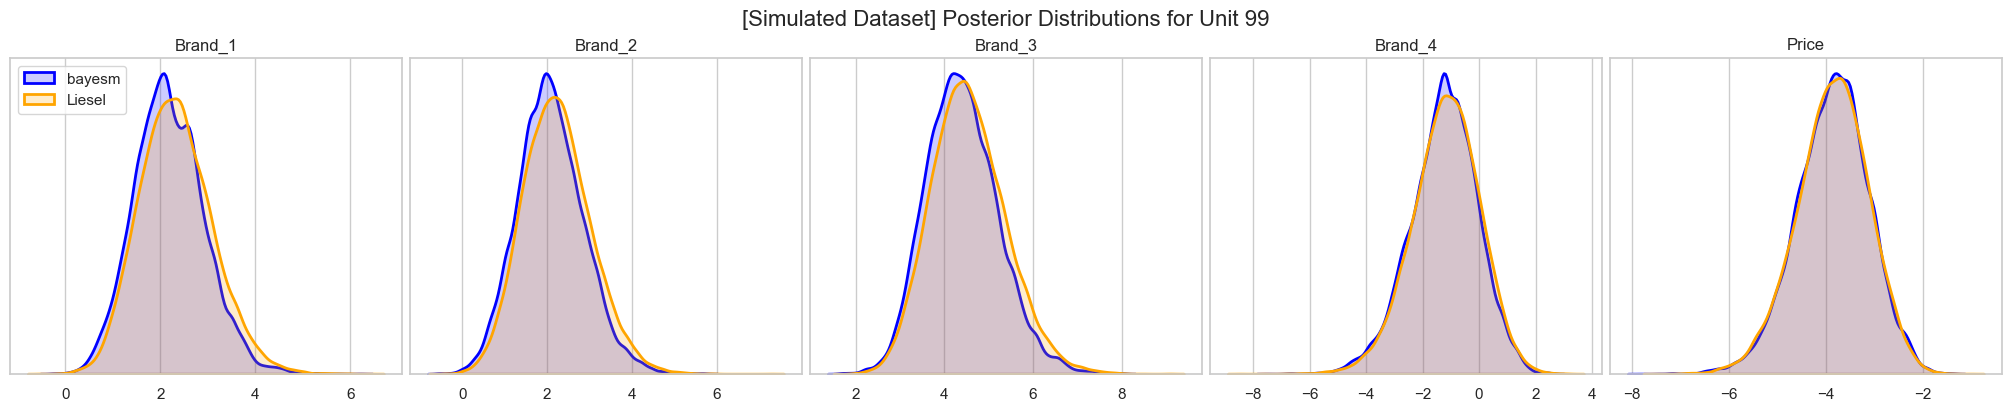

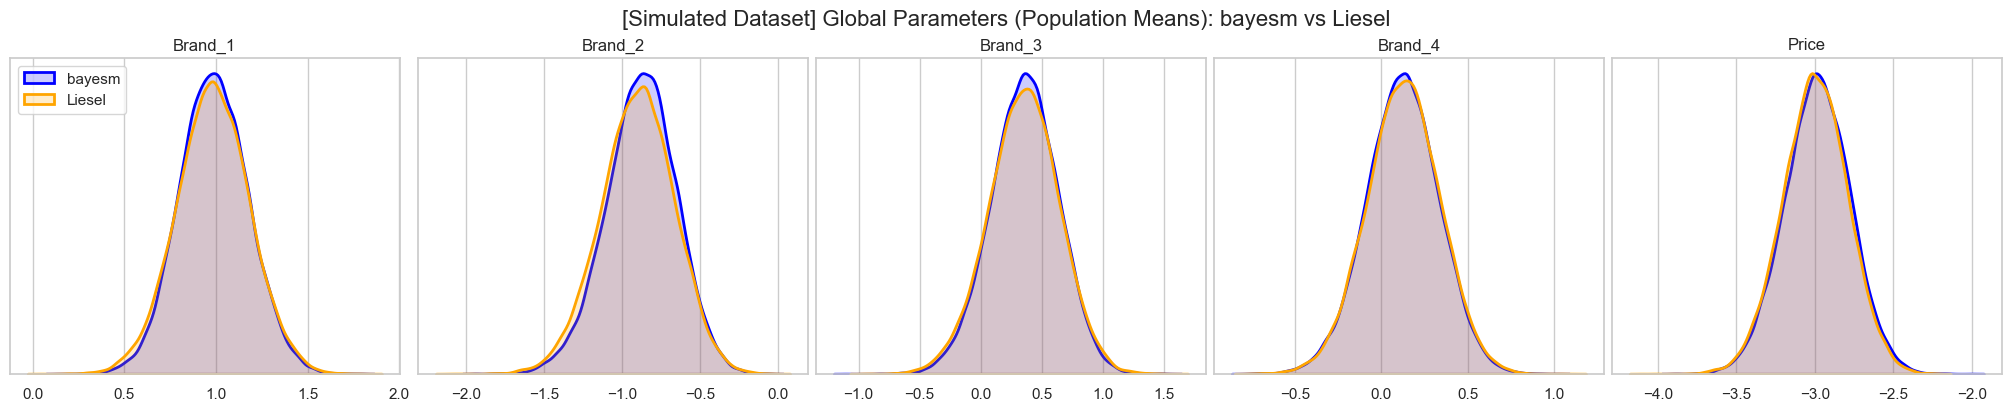

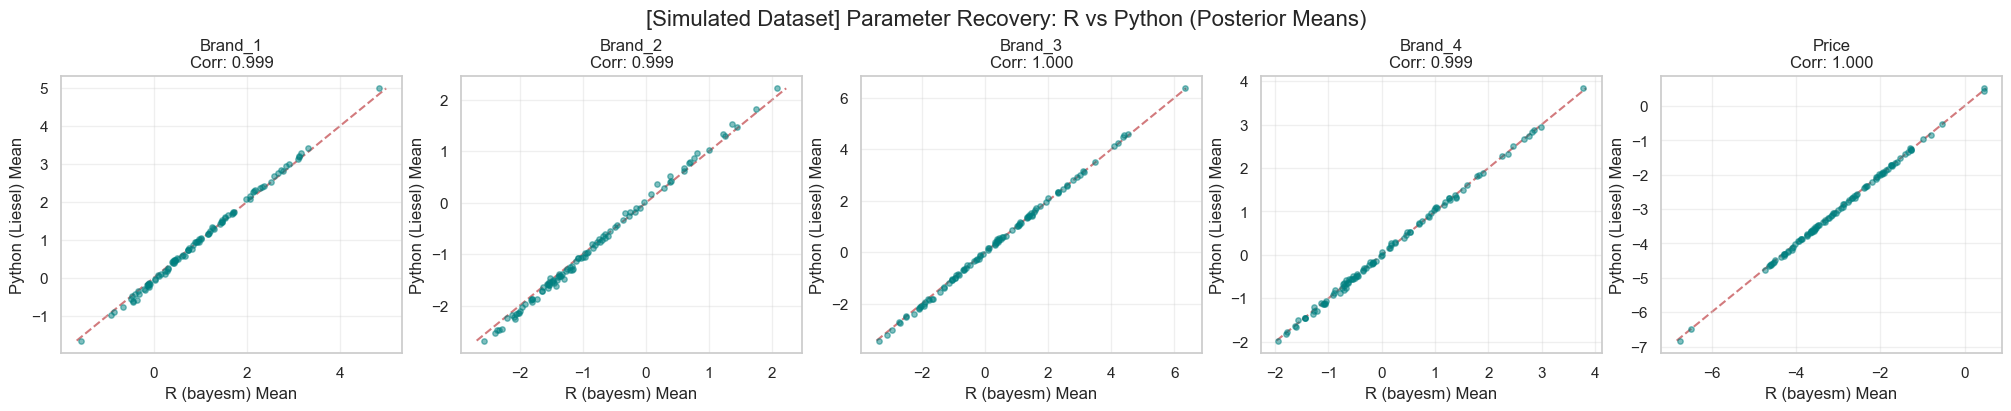

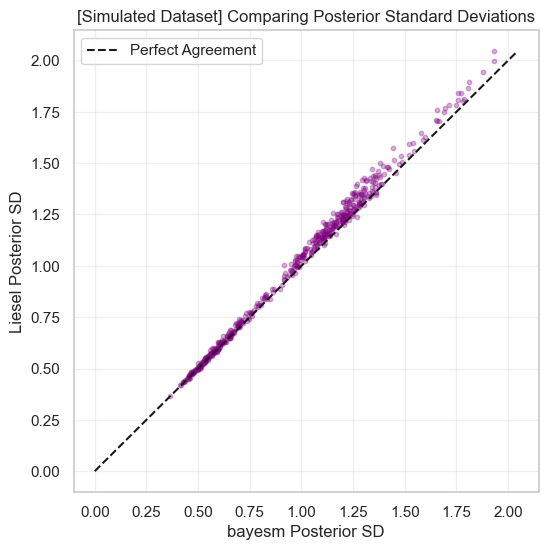

In [22]:
# Simulated Dataset: Model result files 
simulated_liesel = "liesel_output_simulated_40000_samples.pkl"
simulated_bayesm = "bayesm_output_simulated_40000_samples.RData"

# Supply (arbitrary brand) names for features
sim_param_names = ["Brand_1", "Brand_2", "Brand_3", "Brand_4", "Price"]

# Run full analysis
run_full_analysis(
    dataset_name="Simulated Dataset",
    data_dir=data_dir,
    liesel_filename=simulated_liesel,
    bayesm_filename=simulated_bayesm,
    param_names_override=sim_param_names
)

# Camera


Analysis for: Camera Dataset
Loading Liesel data from: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data\liesel_output_camera_40000_samples.pkl
  -> Liesel Beta shape (flattened): (40000, 332, 10)
  -> Liesel Mu shape (flattened): (40000, 10)
Loading bayesm data from: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data\bayesm_output_camera_40000_samples.RData
  -> bayesm Beta shape: (40000, 332, 10)
  -> bayesm Mu shape: (40000, 10)


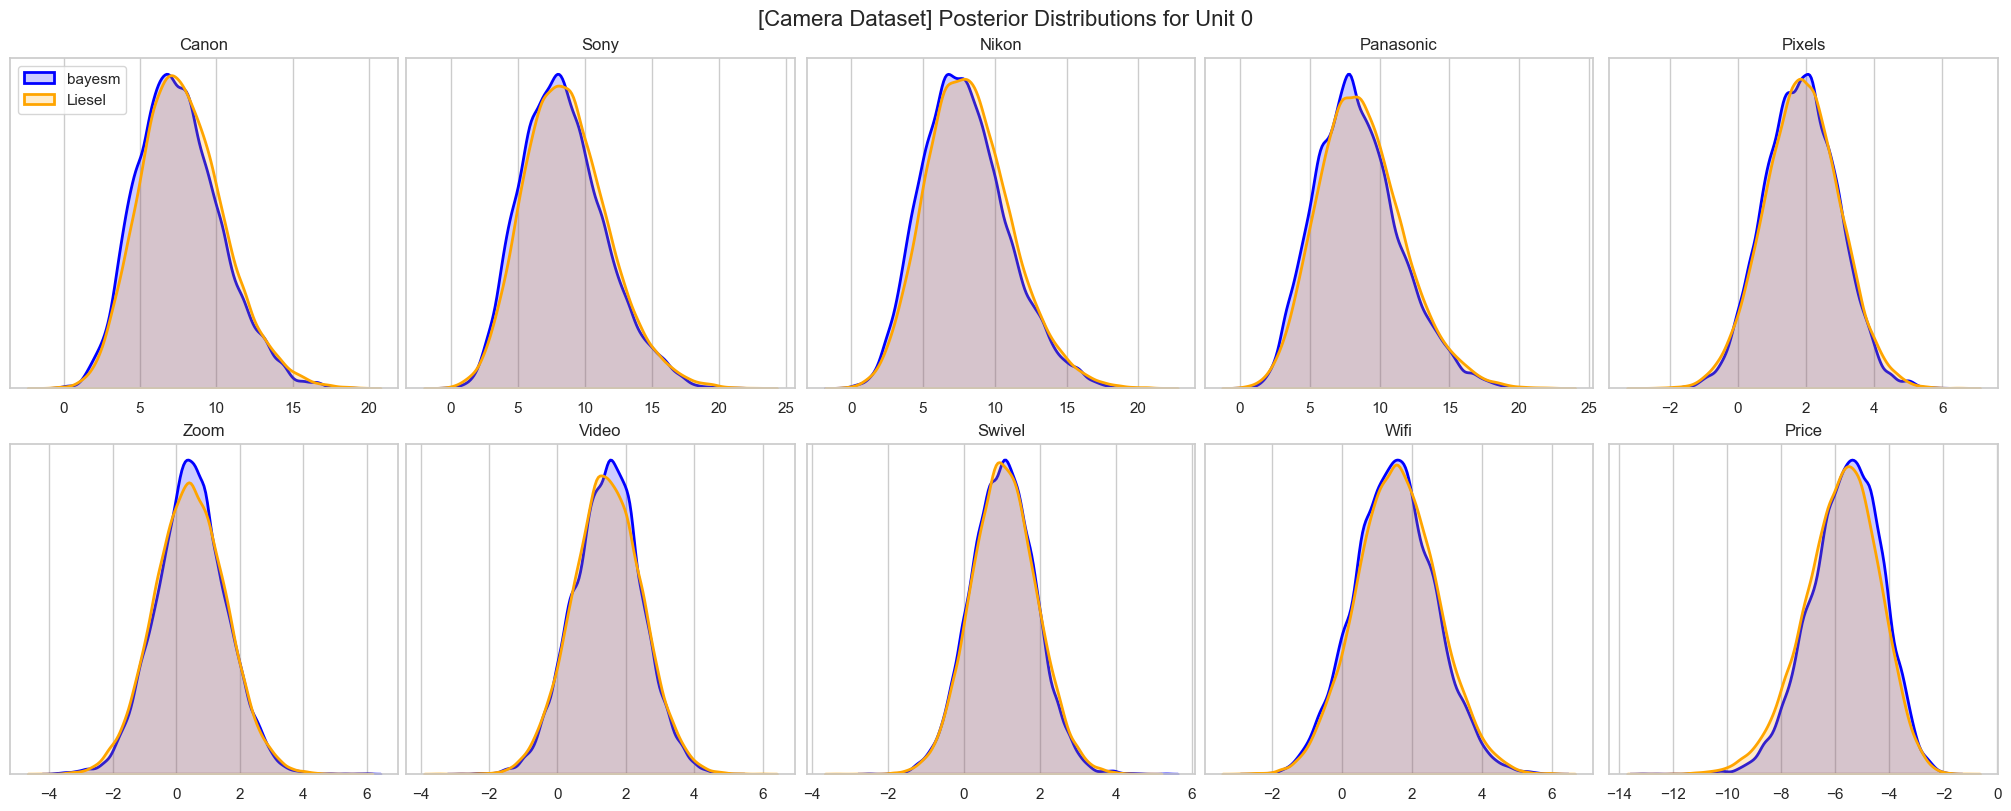

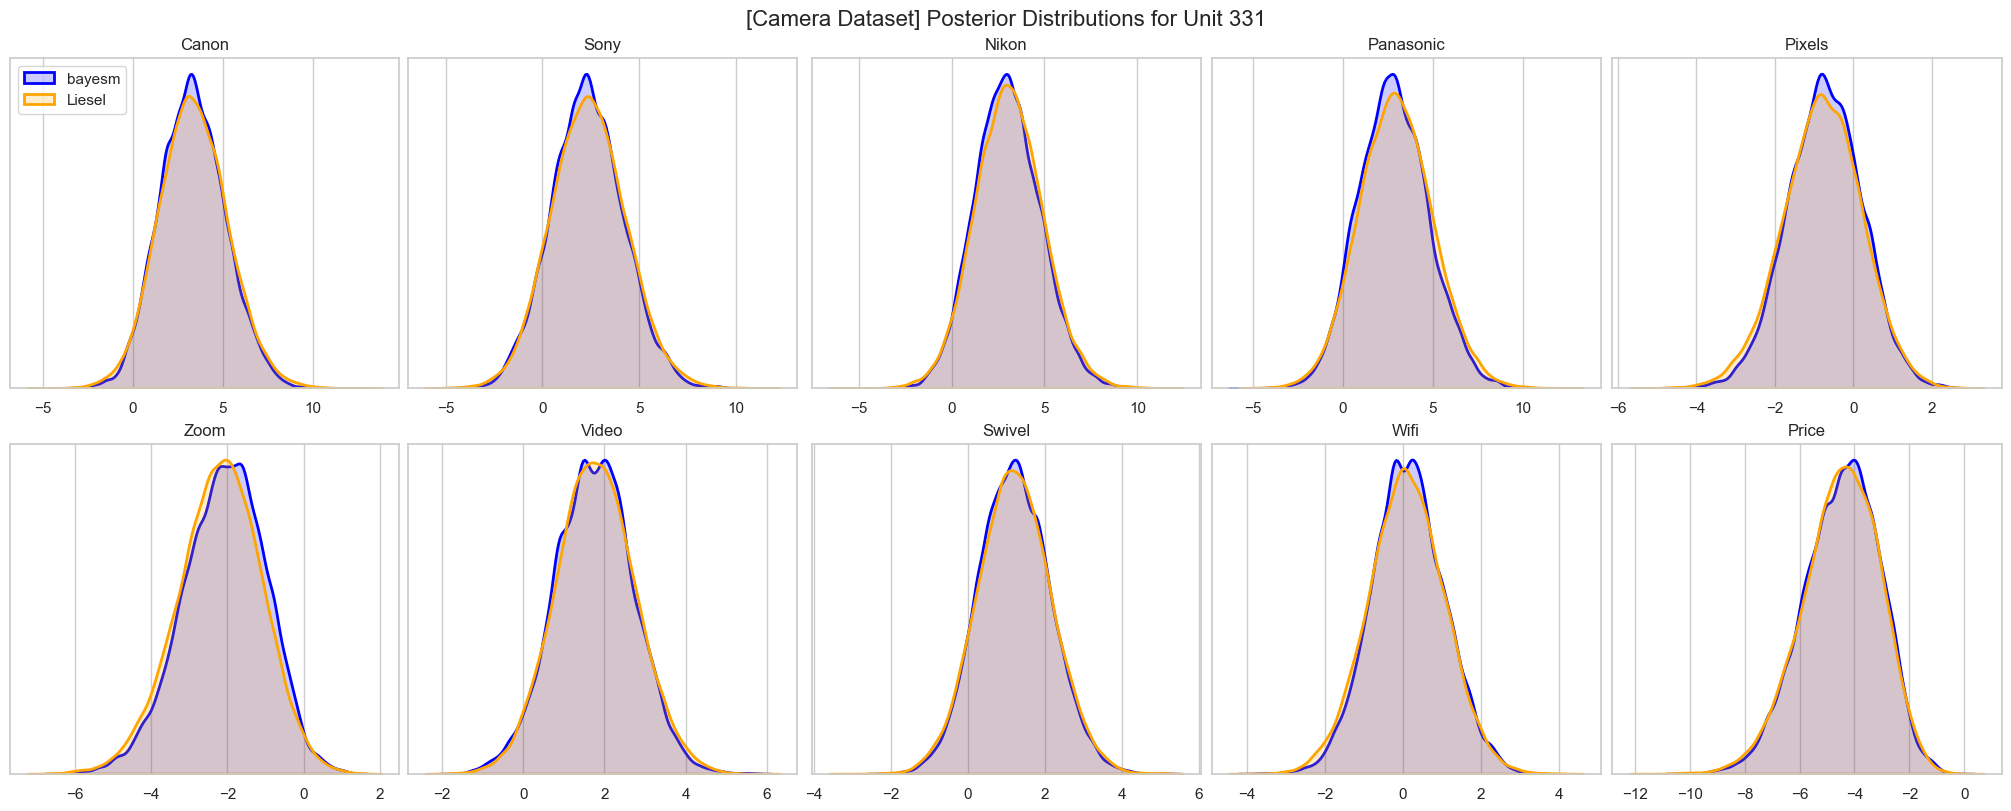

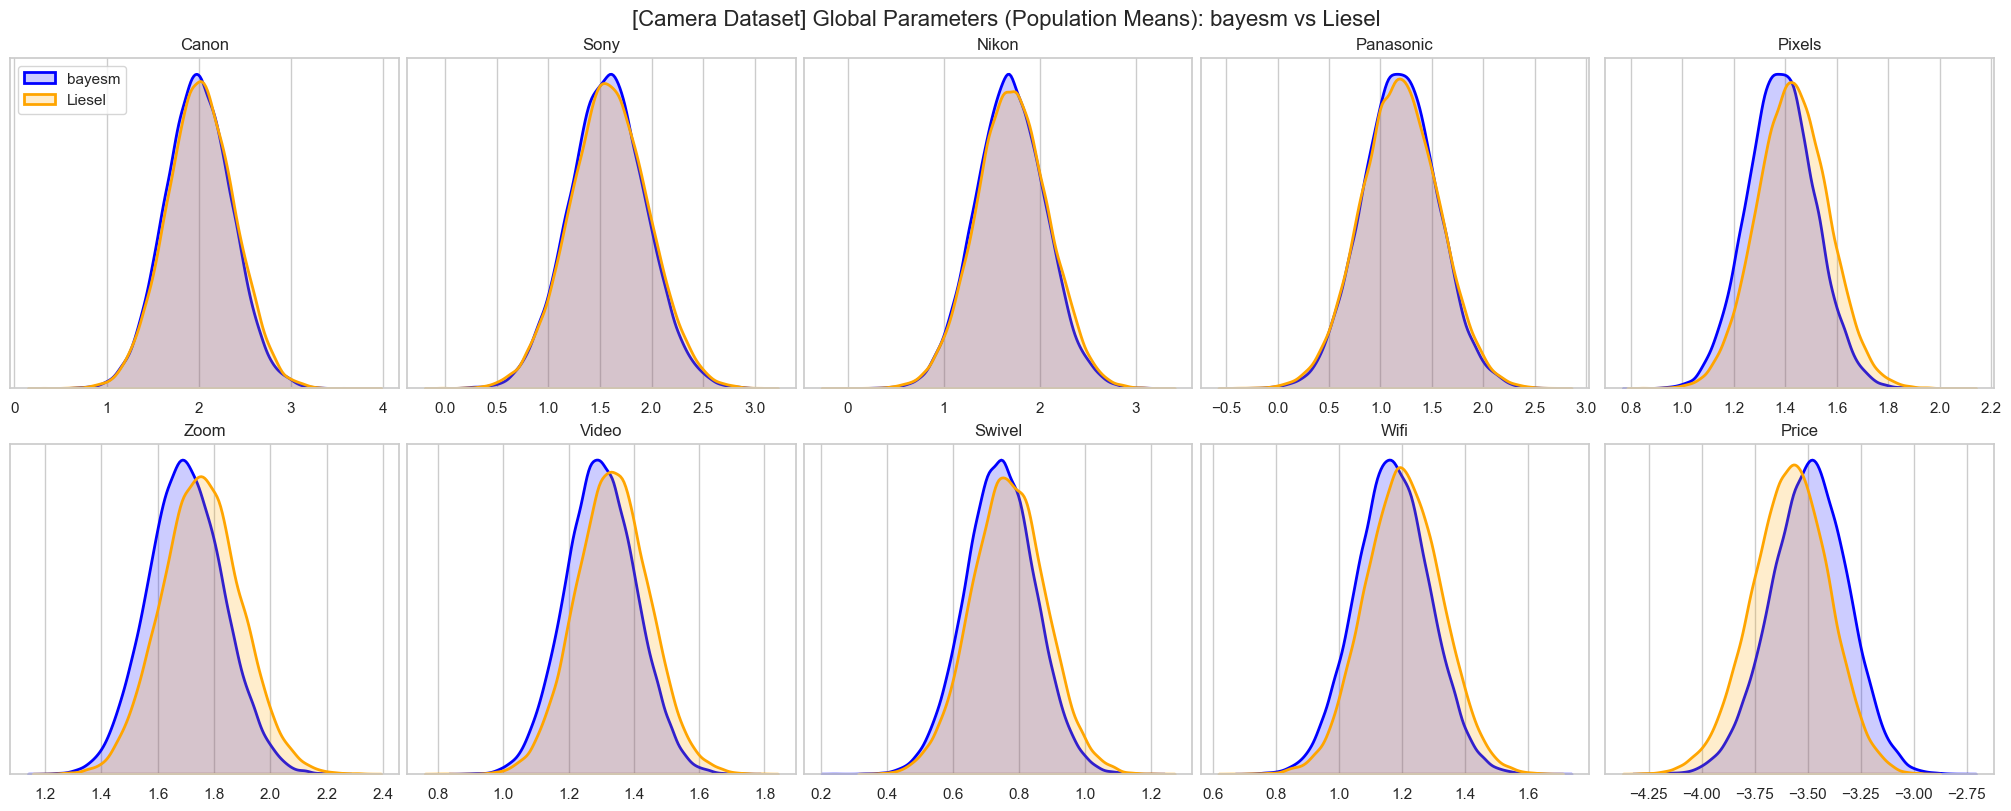

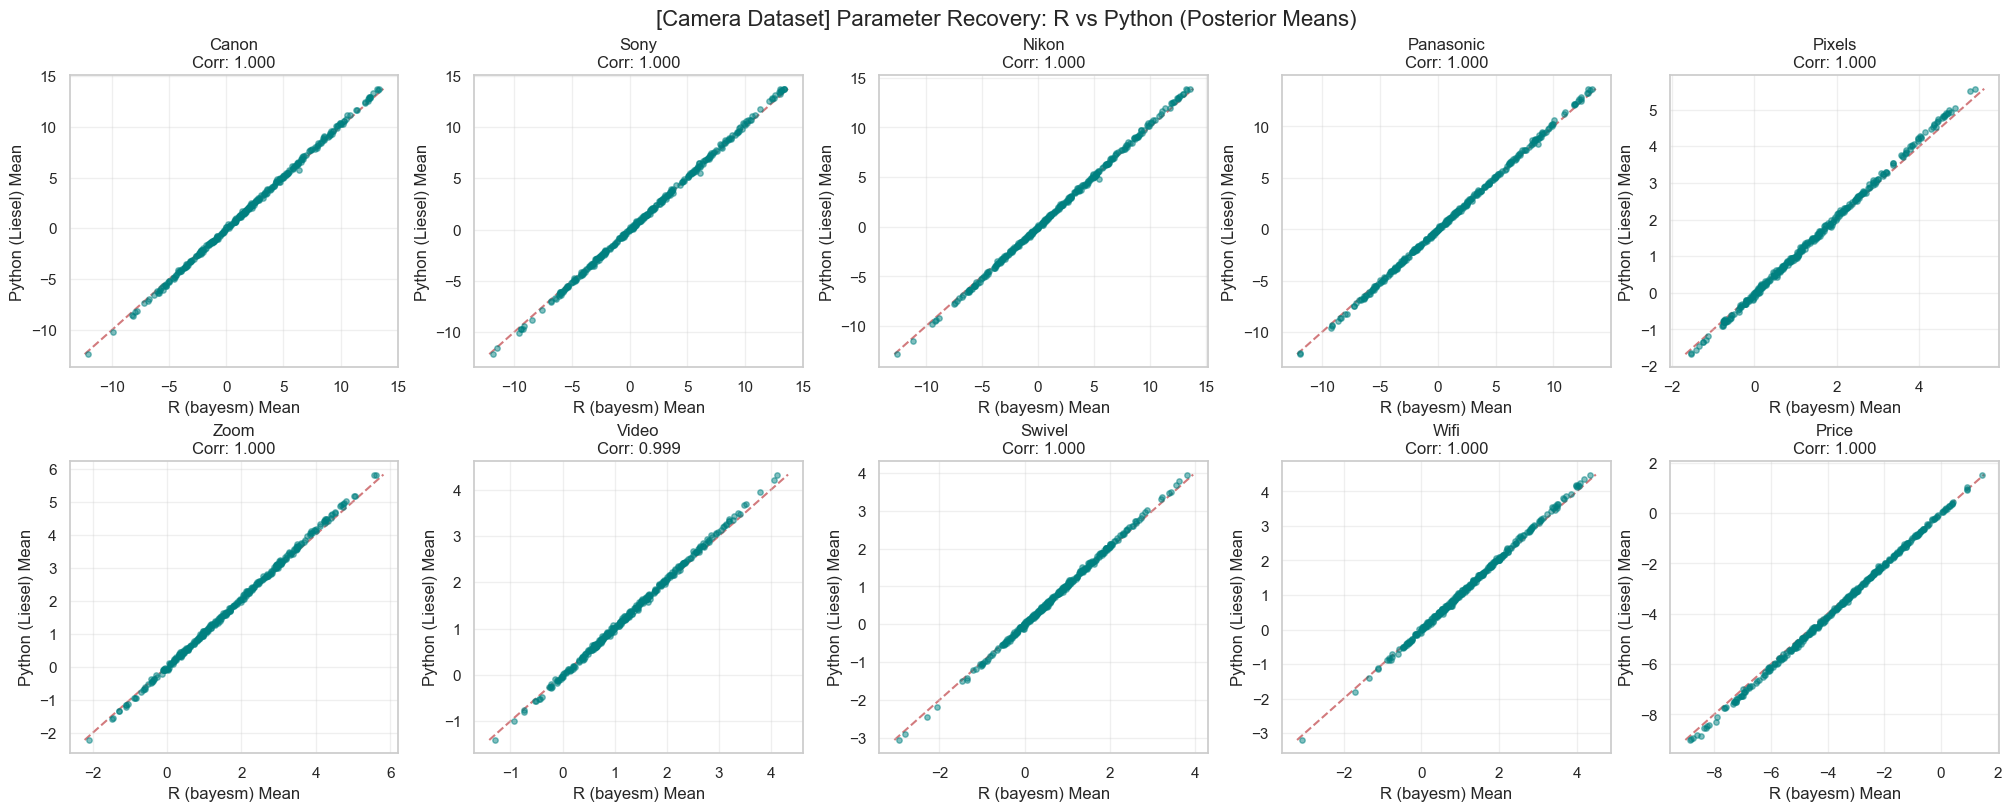

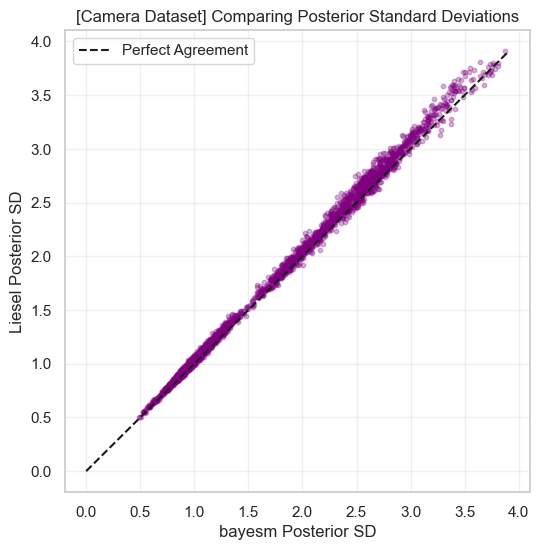

In [23]:
# File names for the camera dataset
camera_liesel = "liesel_output_camera_40000_samples.pkl"
camera_bayesm = "bayesm_output_camera_40000_samples.RData"

# Parameter names for the camera dataset
camera_param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]

# Run the consolidated analysis wrapper
run_full_analysis(
    dataset_name="Camera Dataset",
    data_dir=data_dir,
    liesel_filename=camera_liesel,
    bayesm_filename=camera_bayesm,
    param_names_override=camera_param_names
)

## Margarine Dataset



Analysis for: Margarine Dataset
Loading Liesel data from: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data\liesel_output_margarine_40000_samples.pkl
  -> Liesel Beta shape (flattened): (40000, 516, 10)
  -> Liesel Mu shape (flattened): (40000, 10)
Loading bayesm data from: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data\bayesm_output_margarine_40000_samples.RData
  -> bayesm Beta shape: (40000, 516, 10)
  -> bayesm Mu shape: (40000, 10)


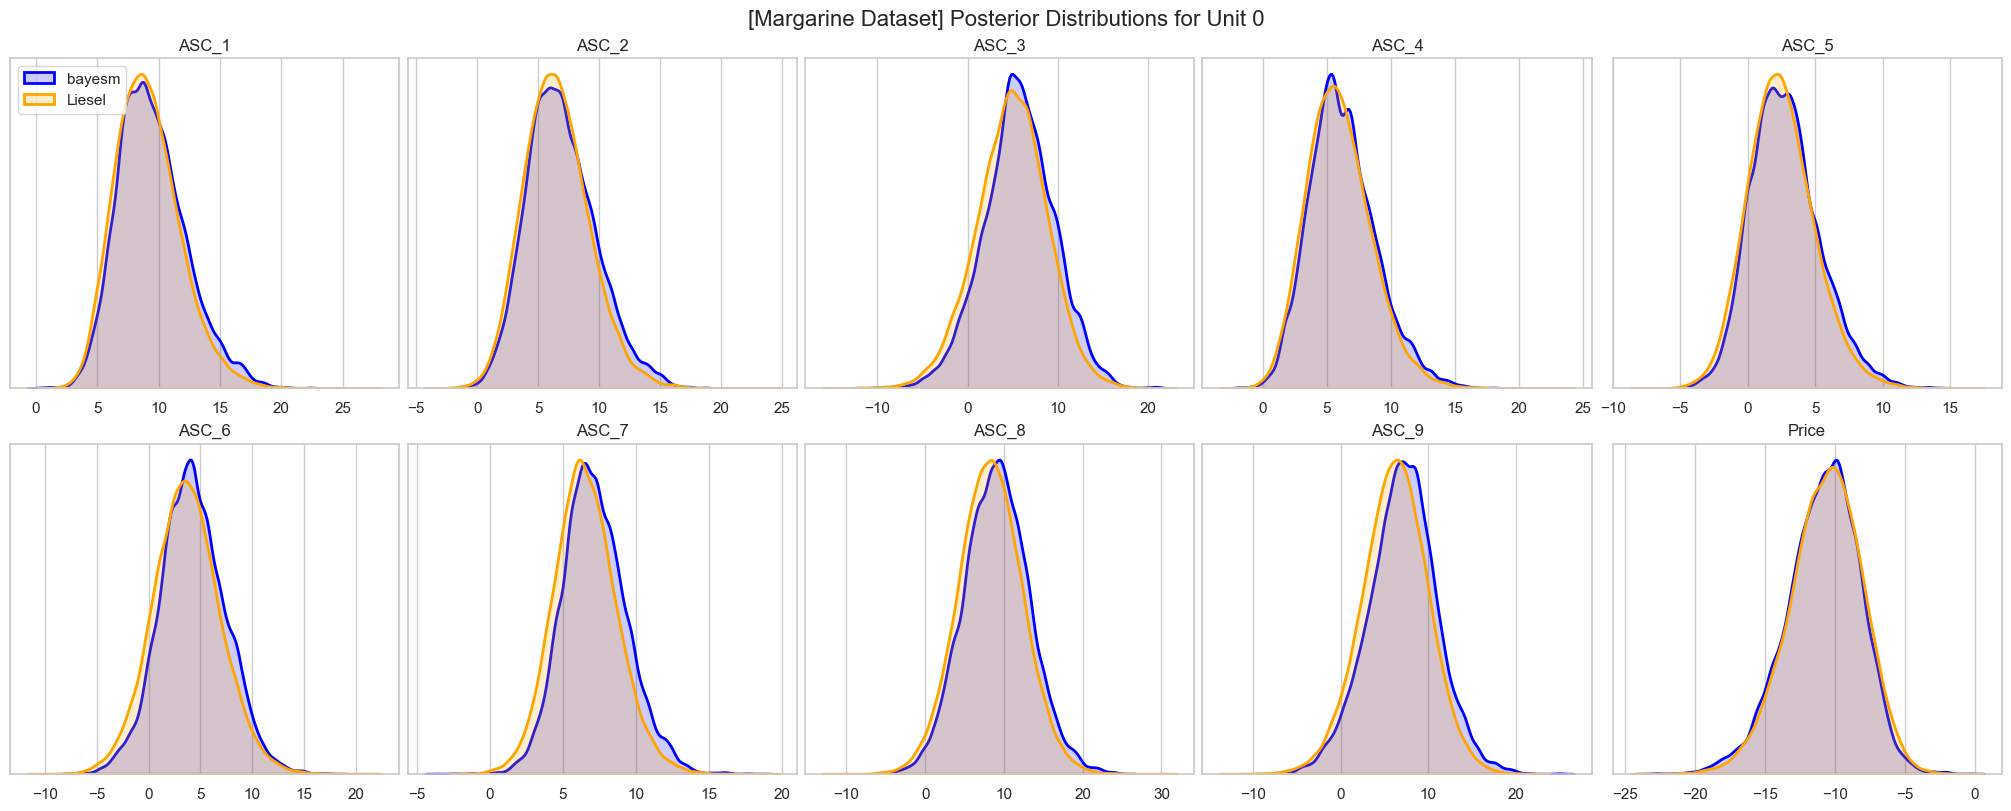

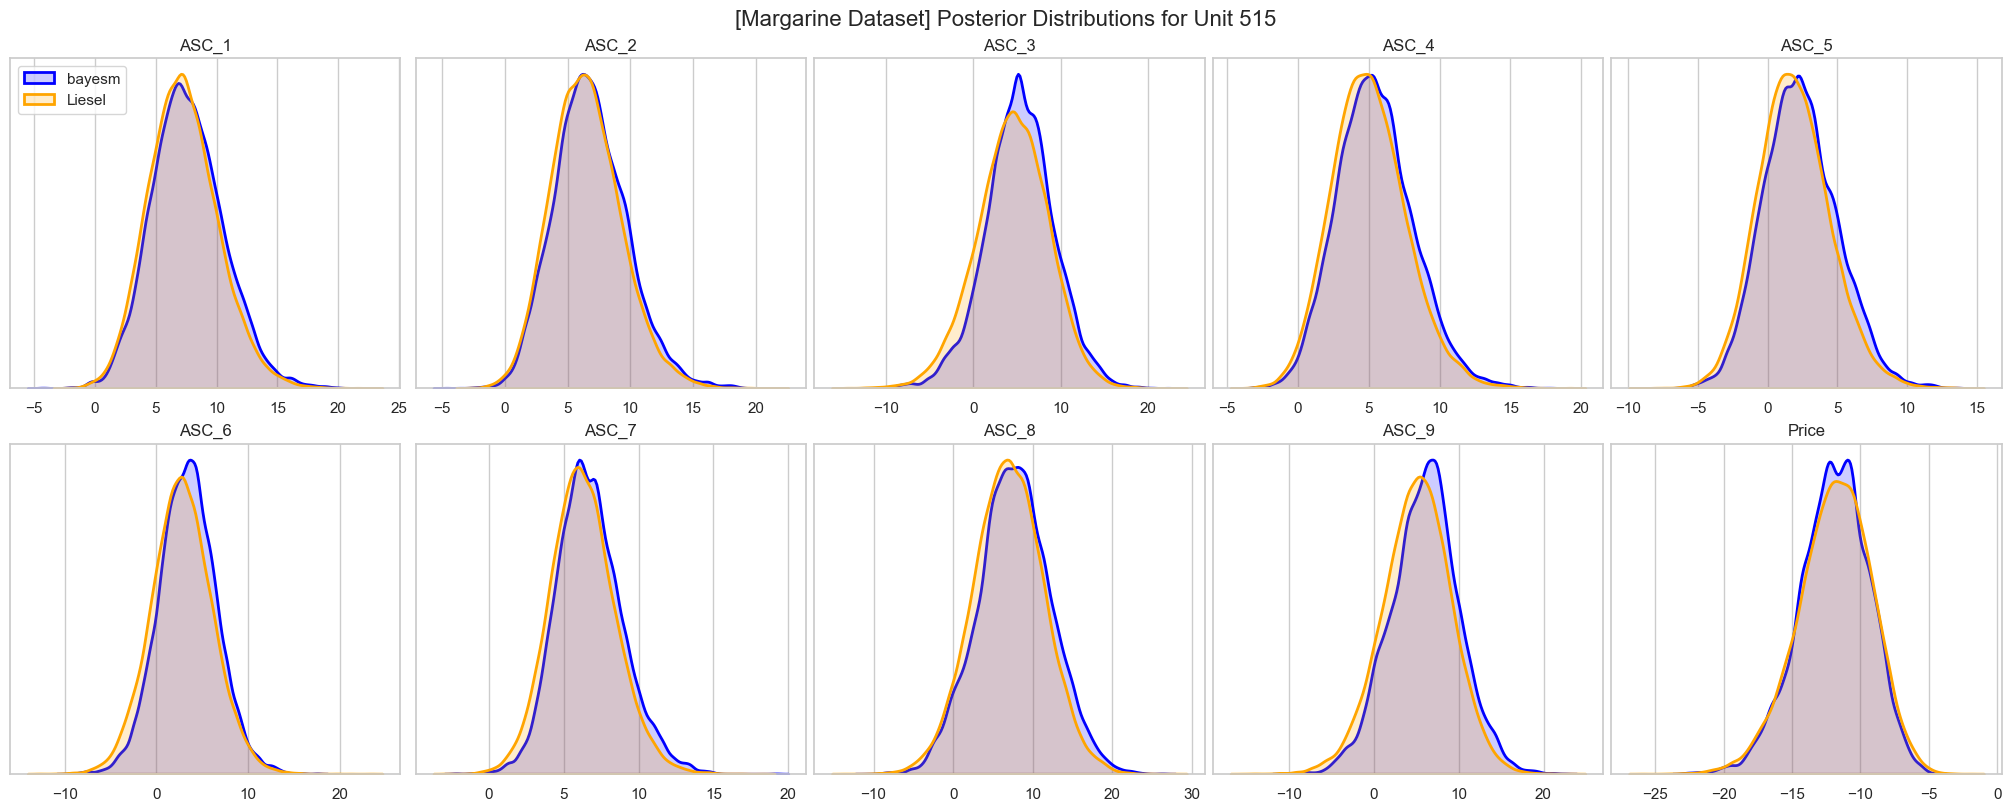

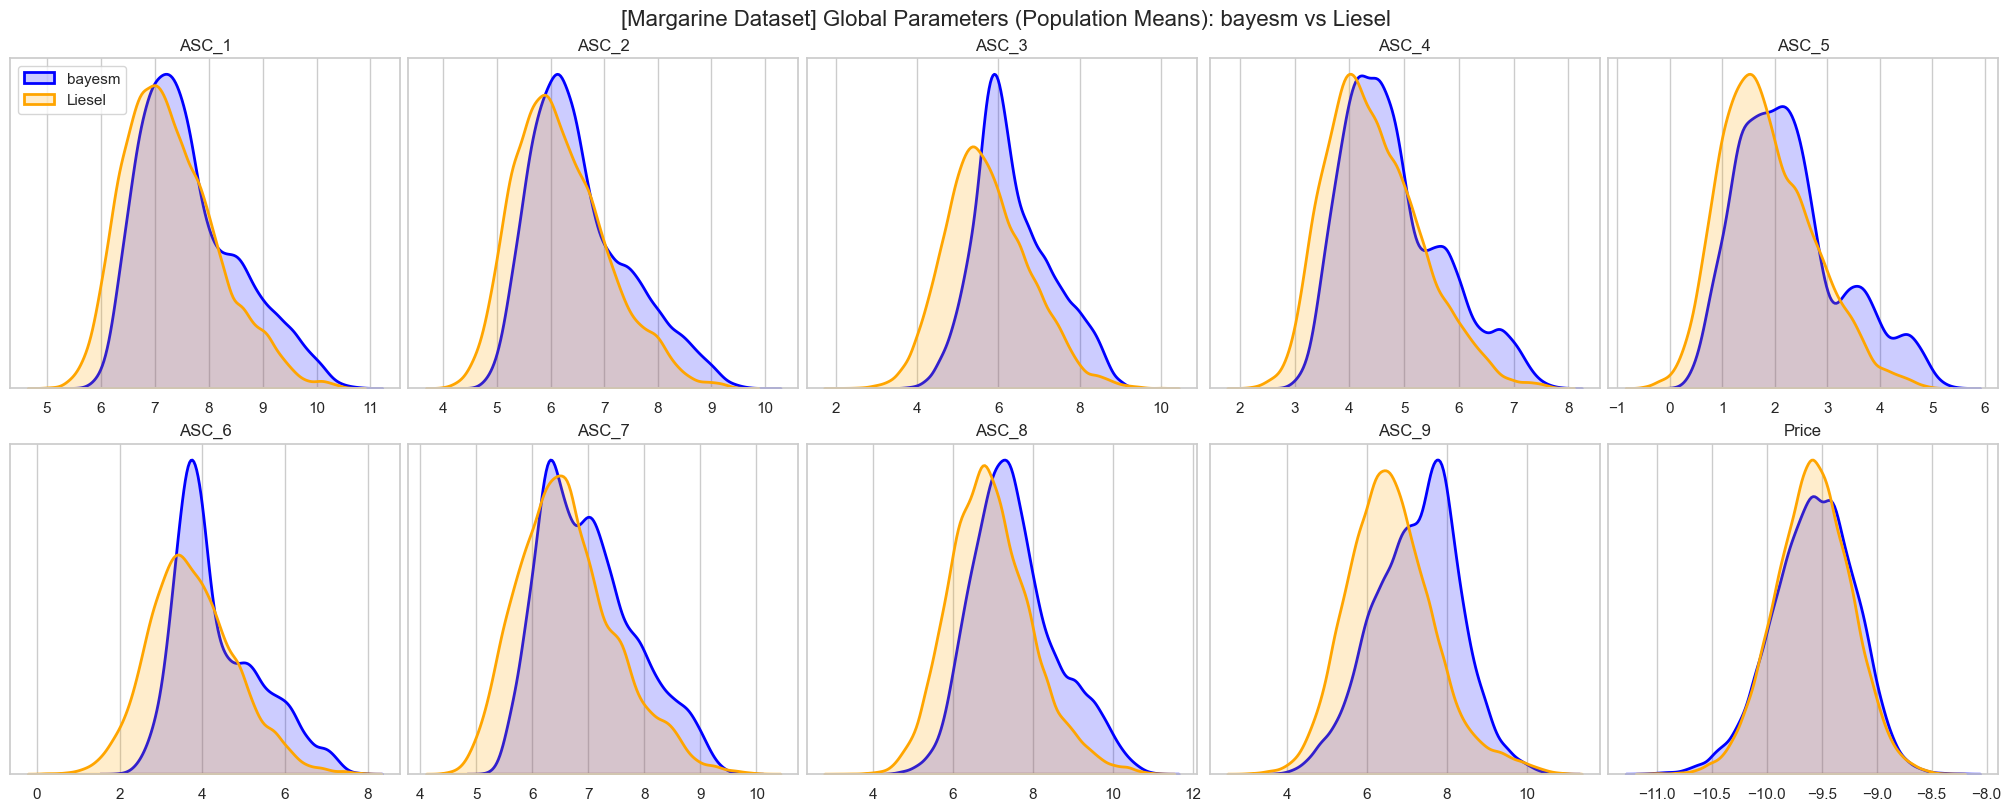

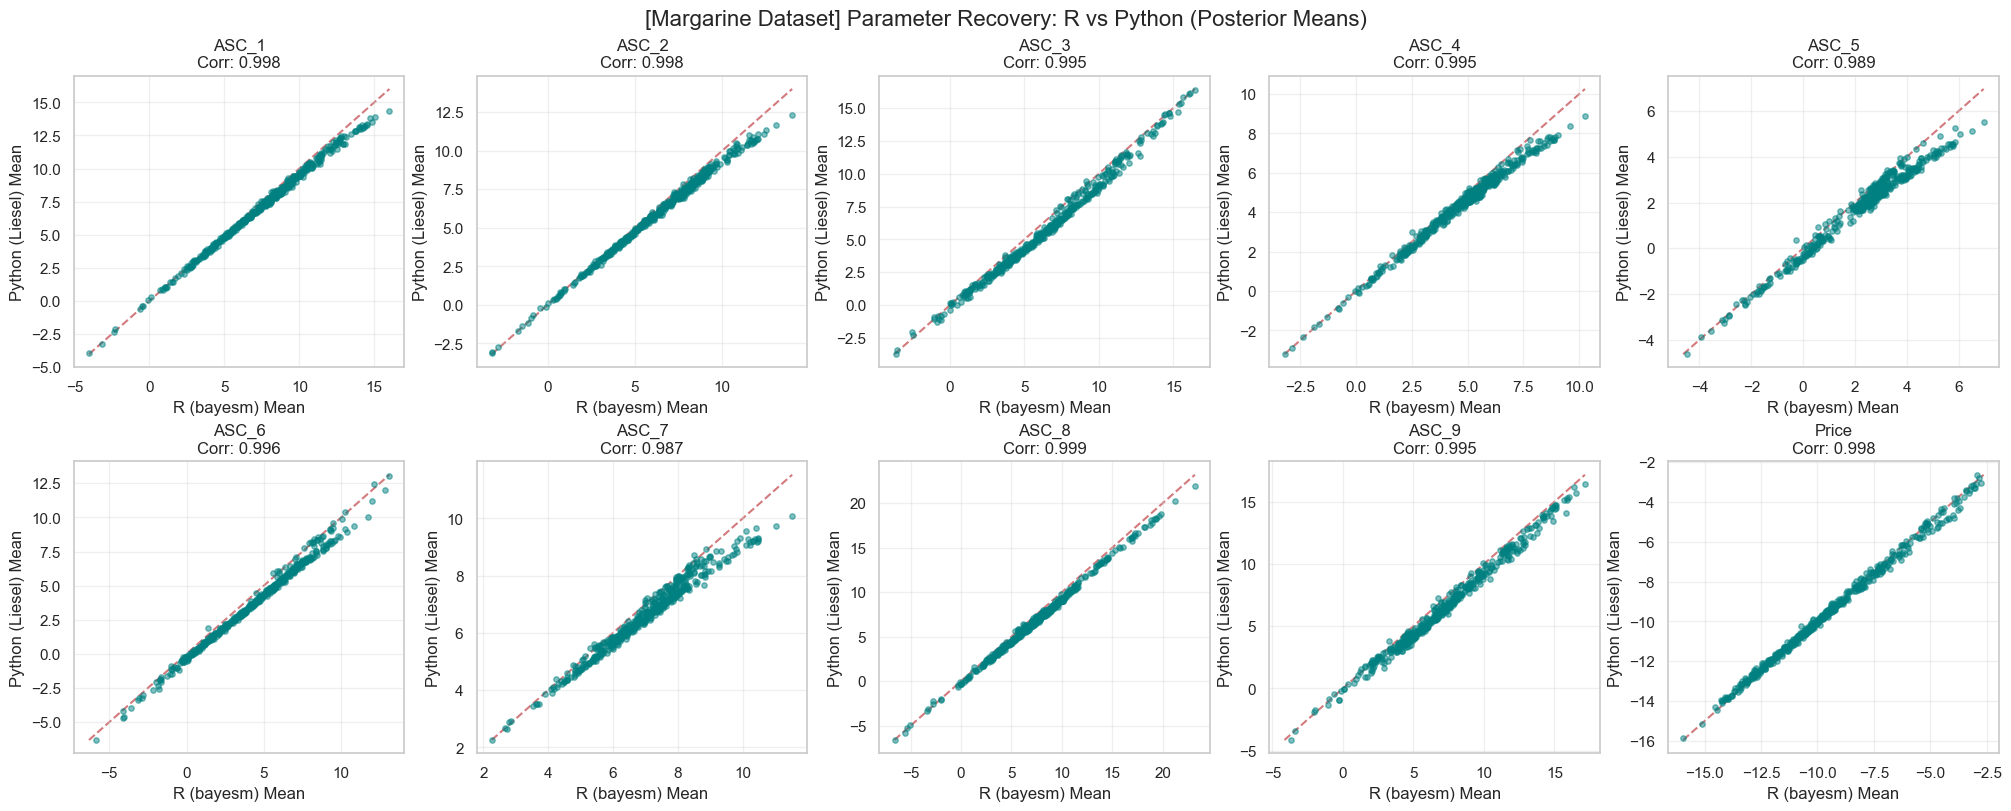

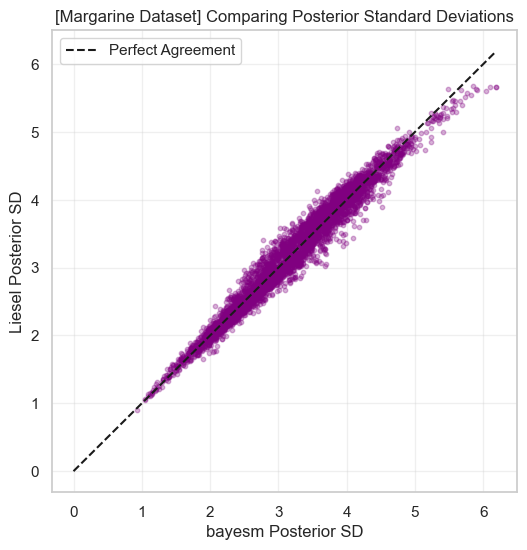

In [24]:
# Margarine names based on the R implementation
margarine_liesel = "liesel_output_margarine_40000_samples.pkl"
margarine_bayesm = "bayesm_output_margarine_40000_samples.RData"

# We supply the exact names expected from the dataset
marg_param_names = ["ASC_1", "ASC_2", "ASC_3", "ASC_4", "ASC_5", "ASC_6", "ASC_7", "ASC_8", "ASC_9", "Price"]

run_full_analysis(
    dataset_name="Margarine Dataset",
    data_dir=data_dir,
    liesel_filename=margarine_liesel,
    bayesm_filename=margarine_bayesm,
    param_names_override=marg_param_names
)